# Credit Card Fraud Detection – Notebook 01  
**Exploratory Data Analysis (EDA) & Preprocessing**

Goal: Understand the dataset, visualize imbalance, check feature distributions, and prepare scaled data.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("magma")
%matplotlib inline

In [15]:
DATA_PATH = '../data/raw/creditcard.csv'   

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.tail(5)

Shape: (284807, 31)

Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [16]:
df.info()
df.describe().T.round(2)   # transpose for better reading

#check for missing values
print("\nMissing values:\n", df.isnull().sum().sum())  

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

## Check class distribution

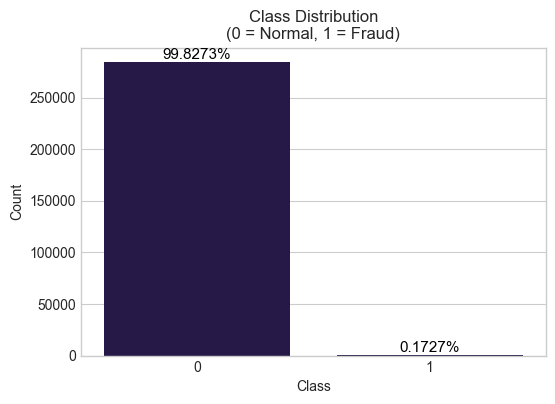

Class
0    284315
1       492
Name: count, dtype: int64

Fraud ratio: 0.1727%


In [20]:
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title('Class Distribution\n(0 = Normal, 1 = Fraud)', fontsize=12)
plt.xlabel('Class')
plt.ylabel('Count')

# Add percentage labels
total = len(df)
for p in plt.gca().patches:
    percentage = f'{100 * p.get_height() / total:.4f}%'
    plt.gca().annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center', fontsize=11, color='black', xytext=(0, 5),
                       textcoords='offset points')

plt.show()

# Exact numbers
print(df['Class'].value_counts())
print("\nFraud ratio: {:.4f}%".format(100 * df['Class'].mean()))

### Class Distribution & Fraud Ratio

**Target variable (`Class`)** — Highly imbalanced dataset

```text
Class
0    284315
1       492


## Transaction Amount by Class

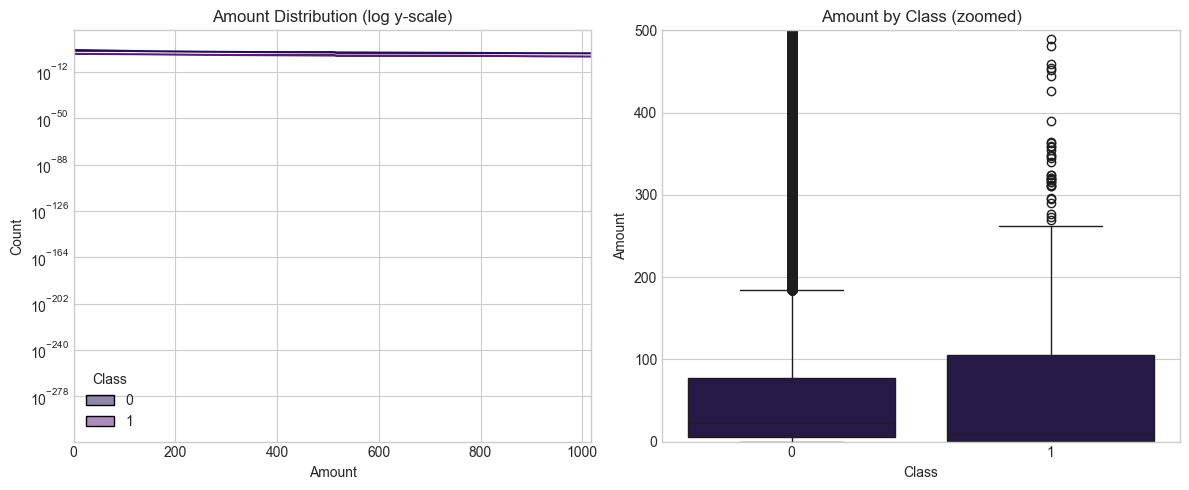

In [21]:
plt.figure(figsize=(12,5))

# Log scale helps because Amount is very skewed
plt.subplot(1,2,1)
sns.histplot(data=df, x='Amount', hue='Class', bins=50, kde=True, log_scale=(False, True))
plt.title('Amount Distribution (log y-scale)')
plt.xlim(0, df['Amount'].quantile(0.99))

plt.subplot(1,2,2)
sns.boxplot(x='Class', y='Amount', data=df)
plt.title('Amount by Class (zoomed)')
plt.ylim(0, 500)

plt.tight_layout()
plt.show()

## insight
Fraud transactions tend to have smaller but more consistent amounts compared to normal ones in many cases.

## Time of day patterns 

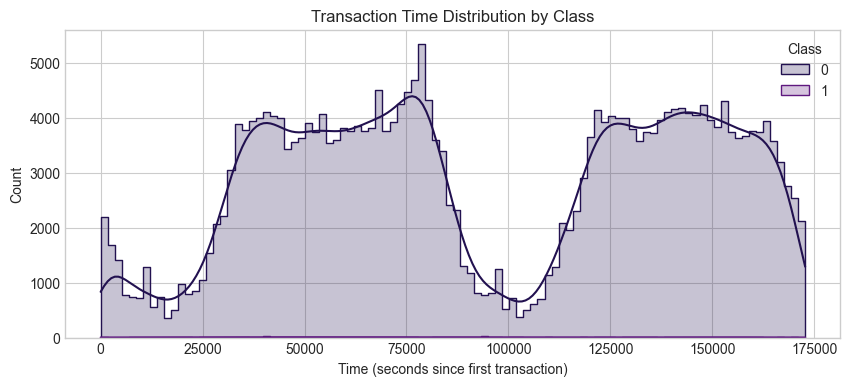

In [22]:
plt.figure(figsize=(10,4))
sns.histplot(data=df, x='Time', hue='Class', bins=100, kde=True, element='step')
plt.title('Transaction Time Distribution by Class')
plt.xlabel('Time (seconds since first transaction)')
plt.show()

## Observation 
Fraud often appears more uniformly across time (no strong daily pattern).

## Correlation heatmap


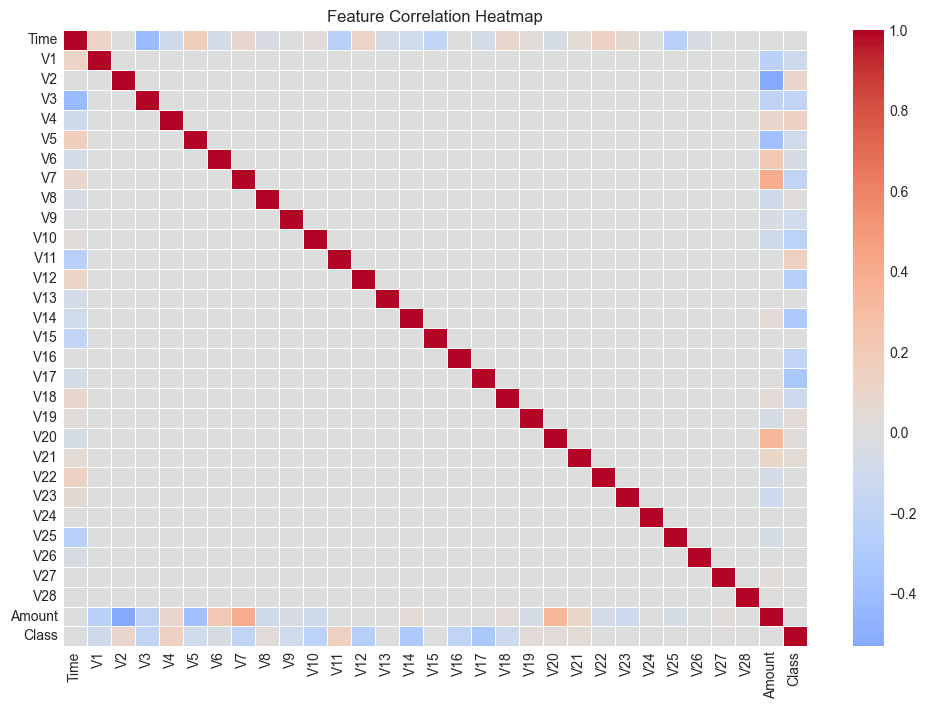

Top features correlated with Class:
Class    1.000000
V11      0.154876
V4       0.133447
V2       0.091289
V21      0.040413
V19      0.034783
V20      0.020090
V8       0.019875
V27      0.017580
V28      0.009536
Name: Class, dtype: float64

Bottom (most negative):
V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
V3    -0.192961
V7    -0.187257
V18   -0.111485
V1    -0.101347
V9    -0.097733
Name: Class, dtype: float64


In [25]:
plt.figure(figsize=(12,8))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

# Top correlations with Class
print("Top features correlated with Class:")
print(corr['Class'].sort_values(ascending=False).head(10))
print("\nBottom (most negative):")
print(corr['Class'].sort_values(ascending=True).head(10))

## Preprocessing: Scaling & Train-Test Split

In [27]:
# Features + target
X = df.drop('Class', axis=1)
y = df['Class']

# Scale all features 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Save scaler for later (API, inference)
import joblib
joblib.dump(scaler, '../models/scaler.pkl')
print("Scaler saved.")

# Stratified split to preserve class ratio in test set
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("\nTrain shape:", X_train.shape, y_train.shape)
print("Test shape: ", X_test.shape,  y_test.shape)
print("Fraud in train: {:.4f}%".format(100 * y_train.mean()))
print("Fraud in test:  {:.4f}%".format(100 * y_test.mean()))

Scaler saved.

Train shape: (227845, 30) (227845,)
Test shape:  (56962, 30) (56962,)
Fraud in train: 0.1729%
Fraud in test:  0.1720%


In [28]:
np.save('../data/processed/X_train.npy', X_train)
np.save('../data/processed/X_test.npy',  X_test)
np.save('../data/processed/y_train.npy', y_train.values)
np.save('../data/processed/y_test.npy',  y_test.values)

print("Processed splits saved.")

Processed splits saved.


## Key Takeaways from EDA
- Extreme class imbalance: ~0.1727% fraud cases
- No missing values
- Features V1–V28 are PCA-transformed → already centered/scaled
- Amount is right-skewed; fraud cases often smaller amounts
- Strong negative correlations: V14, V17, V12, V10, V16 with fraud
- Time shows no strong daily pattern for fraud

## Next Notebook
02-isolation-forest.ipynb or 03-autoencoder-pytorch.ipynb